# Gold fcc111 infinite slab

> Willem de Kleijne | March 17, 2026  
>
> Sample: Gold fcc111    

In [11]:
import abtem
import numpy as np
import matplotlib.pyplot as plt

## Gold Unitcell


(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='x [Å]', ylabel='y [Å]'>)

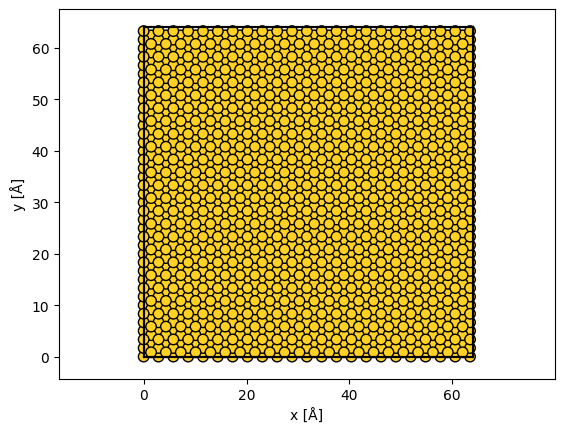

In [12]:
from ase.build import fcc111
lc=4.08
unit_cell =abtem.orthogonalize_cell( fcc111('Au', size=(2, 2, 3), a=lc, periodic=True,orthogonal=False))
super_cell = unit_cell * (12,7,1)
del super_cell[super_cell.positions[:,0] > 64]
del super_cell[super_cell.positions[:,1] > 64]
super_cell.cell[0,0] = 64
super_cell.cell[1,1] = 64 # make the cells square
abtem.show_atoms(super_cell)

## Potential

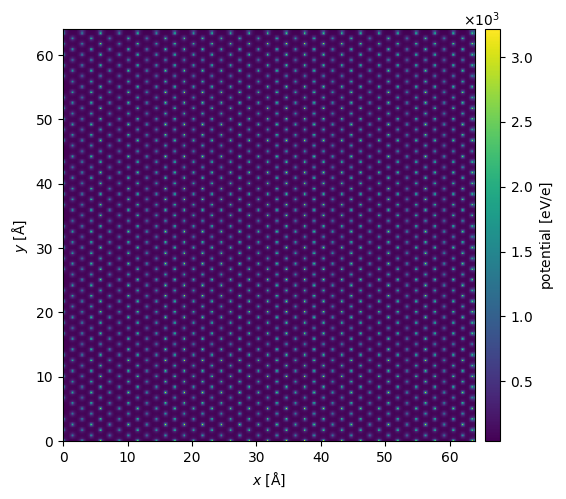

In [13]:
potential = abtem.Potential(
    super_cell,
    gpts=(512,512),         # to ensure that the size of diffraction pattern is 512x512
    slice_thickness= lc/8,
    device='cpu',
).build(
    lazy=False
)

potential.show(
    cbar=True
);

tasks:   0%|          | 0/2 [00:00<?, ?it/s]

tasks:   0%|          | 0/2 [00:00<?, ?it/s]

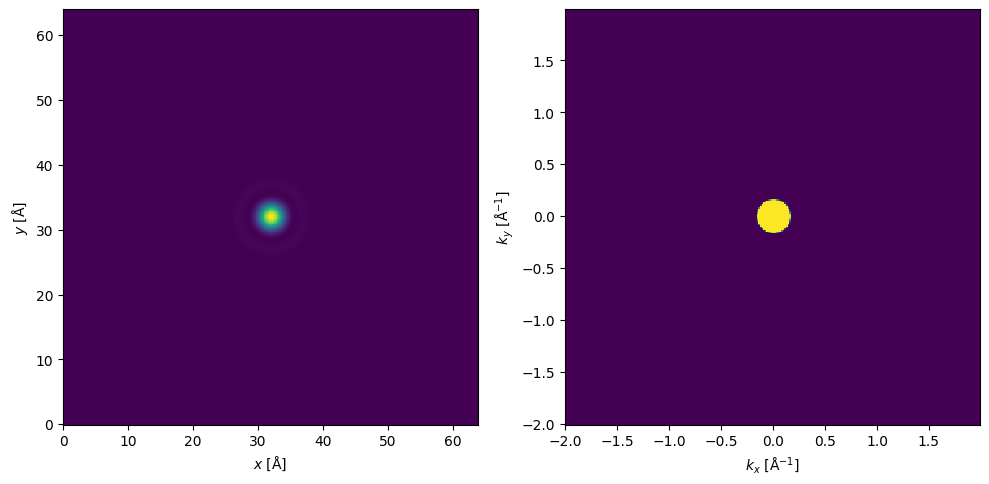

In [14]:
energy = 10e3 # eV
semiangle_cutoff = 20 # mrad


aberrations = {
    "C10":0,
}

probes = abtem.Probe(
    energy=energy,
    semiangle_cutoff=semiangle_cutoff,
    aberrations=aberrations,
    device='cpu',
).match_grid(
    potential
)

fig, axs = plt.subplots(1,2,figsize=(10,5))
probes.show(ax=axs[0])
probes.build().diffraction_patterns(max_angle=None).crop(gpts=(256,256)).show(ax=axs[1])
fig.tight_layout()

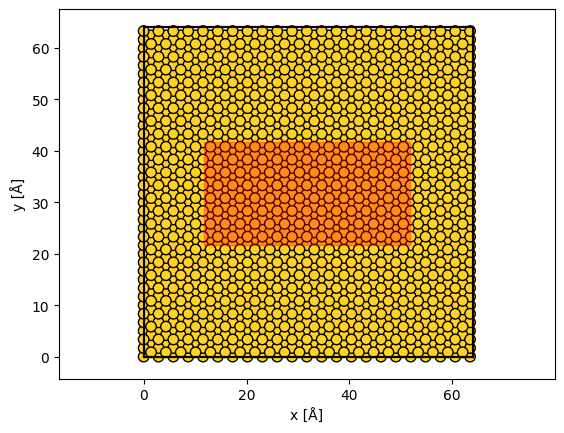

In [15]:
pos = super_cell.positions

x_extent = pos[:, 0].max() - pos[:, 0].min()
y_extent = pos[:, 1].max() - pos[:, 1].min()

grid_scan = abtem.GridScan(
    start = (x_extent/2-20, y_extent/2-10),
    end = (x_extent/2+20, y_extent/2+10),
    gpts=(48+1,24+1),
    endpoint=True
)

fig,ax = plt.subplots()
abtem.show_atoms(super_cell,ax=ax)
grid_scan.add_to_plot(ax)

detector = abtem.PixelatedDetector(
    max_angle=None
)

In [16]:
measurement = probes.scan(
    potential,
    grid_scan,
    detector,
).compute(
)
dose = 1e7
measurement_noisy = measurement.crop(gpts=(256,256)).poisson_noise(dose)

tasks:   0%|          | 0/30 [00:00<?, ?it/s]

In [17]:
dataset_noisy = measurement_noisy.to_quantem()
dataset_noisy

Dataset(shape=(49, 25, 256, 256), dtype=float32, name='DiffractionPatterns')
  sampling: [0.83333333 0.83333333 0.015625   0.015625  ]
  units: ['A', 'A', 'A^-1', 'A^-1']
  signal units: 'arb. units'

In [18]:
dataset_noisy.save(f"/home/wdekleijne/git-repos/willem-playground/data/crystalline_{semiangle_cutoff}mrad_{energy:.1e}kev_{dose:.0e}-dose_3_layer_256x256.zip",mode='o')